# Industrial Surface Defect Classification using Transfer Learning 

## Objective

The aim of this assignment is to automatically classify surface defects in steel materials using real-world industrial image data and a transfer learning approach.

Surface defects such as cracks, scratches, inclusions, and pits commonly occur during manufacturing processes and can significantly affect product quality. Manual inspection of these defects is time-consuming, inconsistent, and difficult to scale.

In this assignment, we use a dataset containing steel surface images belonging to six different defect categories:
- Crazing  
- Inclusion  
- Patches  
- Pitted Surface  
- Rolled-in Scale  
- Scratches  

All defect types originate from the same manufacturing domain, and learning from all categories together allows the model to capture shared texture and structural patterns present across industrial surfaces.

The problem statement for this assignment is:

> **Given a steel surface image, predict the type of surface defect present in the image using a pretrained convolutional neural network.**

To solve this problem efficiently, we apply **transfer learning** by reusing a pretrained `MobileNetV2` model as a feature extractor and training only a lightweight classification head. This demonstrates how deep learning models can be adapted to real industrial use cases using limited data and computational resources.

## Business Value

In manufacturing industries such as steel, automotive, and heavy engineering, surface defects can directly impact product quality, safety, customer satisfaction, production cost, and rework rates.

Traditional inspection methods rely heavily on human inspectors, which introduces inconsistency in defect detection. Manual inspection also comes with high operational costs and scalability limitations.

By applying transfer learning, organisations can:
- Reuse pretrained visual intelligence instead of training models from scratch  
- Reduce development and training time  
- Achieve reliable defect detection even with smaller datasets  
- Deploy lightweight models suitable for real-time or edge-based inspection systems

## Dataset Description

This assignment uses the **NEU Surface Defect Dataset**, a real-world industrial dataset commonly used in manufacturing research and automated inspection systems.

### Dataset Characteristics:
- Images represent steel surface textures captured under industrial conditions  
- Each image belongs to one of six defect categories:
  - Crazing  
  - Inclusion  
  - Patches  
  - Pitted Surface  
  - Rolled-in Scale  
  - Scratches  
- Images are originally grayscale
- The dataset is reasonably balanced across classes  


#### Why this dataset?

- It represents a real industrial computer vision problem
- Defect patterns are texture-based, making it ideal for demonstrating transfer learning  
- The dataset size is moderate, encouraging the use of **partial transfer learning** rather than full model retraining  

## Flow Diagram

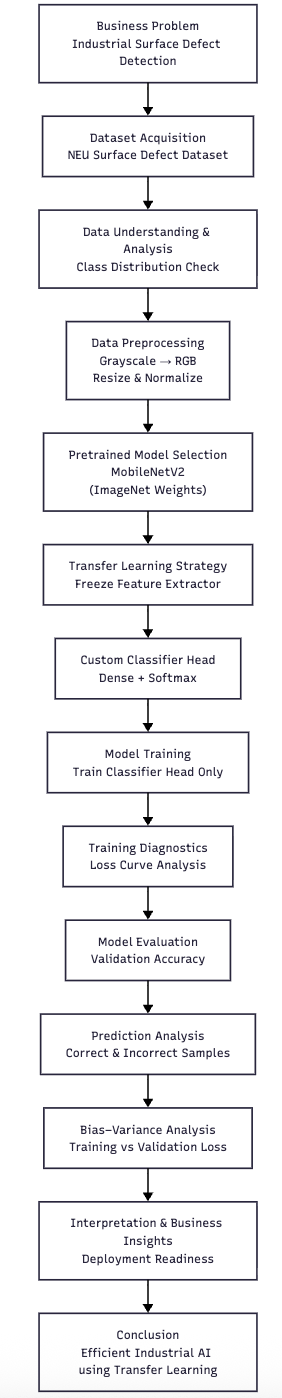

**Note:** You are free to choose any pre-trained model from the available ones. However, the architecture we suggest for this assignment is `MobileNetV2` with "ImageNet" weights.

The choice of libraries, frameworks, and backbones for this assignment are up to you. Before starting this assignment, please ensure that your environment meets the following requirements.


**Software Requirements**

- *Python version*: > Python3.11  
- *Execution environment*: Jupyter Notebook / JupyterLab / VS Code Notebook  
- *Operating system*: macOS, Linux, or Windows  


**Hardware Requirements**
- A GPU-powered training would be optimal, and would require installation of proper libraries and CUDA
- However, CPU-only execution might also be sufficient, and would work without CUDA

### Import Necessary libraries

In [21]:
# Import Required Libraries

# --- Core ---
import os
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Deep learning: TensorFlow / Keras ---
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.utils import image_dataset_from_directory

# --- Evaluation ---
from sklearn.metrics import confusion_matrix, classification_report, recall_score

# --- Reproducibility: one seed for python, numpy and tensorflow ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

sns.set_style("whitegrid")

print("TensorFlow  :", tf.__version__)
print("GPU devices :", tf.config.list_physical_devices("GPU") or "none - training will run on CPU")

TensorFlow  : 2.21.0
GPU devices : none - training will run on CPU


## 1. Data Loading and Preparation 

<font color=red>[10 marks]</font>

In any machine learning workflow, understanding and preparing the data correctly is a critical first step. Before building a deep learning model, it is important
to examine how the dataset is structured, how labels are assigned, and how images are preprocessed for training.

This section includes the following steps:
- Understanding the dataset organisation
- Verifying class labels and distributions
- Applying appropriate image transformations for transfer learning
- Development of train loader and validation loader

### 1.1 Dataset Understanding and Structure 

<font color=red>[4 marks]</font>

The NEU Surface Defect Dataset consists of real-world grayscale images collected from steel manufacturing processes. Each image belongs to one of six surface defect categories.

The dataset is already split into **training** and **validation** sets, and images are organised into class-specific folders. This structure allows us to use PyTorch’s `ImageFolder` utility, which automatically assigns labels based on directory names.

The same directory-based structure is also compatible with TensorFlow, allowing the dataset to be loaded directly using `tf.keras.utils.image_dataset_from_directory`, which infers class labels from folder names in a similar manner.



Before proceeding, we load the dataset and verify:
- Number of images in training and validation sets
- Mapping between class names and numeric labels

#### **1.1.1** Load Images and Labels  <font color=red>[3 marks]</font>

Load the training and validation datasets and check the number of images and the number of categories present

In [ ]:
# Load training and validation images + labels
train_dir = "NEU-DET/train/images"
val_dir   = "NEU-DET/validation/images"

# MobileNetV2 expects 224x224 RGB input.
# NEU-DET images are grayscale, so color_mode="rgb" loads them as 3 identical channels.

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    train_dir,
    labels="inferred",          # labels are taken from the sub-folder names
    label_mode="int",           # integer labels -> SparseCategoricalCrossentropy later
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,              # keep validation order fixed so predictions stay comparable
)

# --- Dataset statistics ---
class_names = train_ds.class_names          # folder names, sorted alphabetically
num_classes = len(class_names)

# file_paths holds every image path -> its length is the number of images
num_train = len(train_ds.file_paths)
num_val   = len(val_ds.file_paths)

print(f"\nNumber of categories : {num_classes}")
print(f"Training images      : {num_train}")
print(f"Validation images    : {num_val}")
print("\nClass name -> label mapping:")
for label, name in enumerate(class_names):
    print(f"  {label} : {name}")

# Sanity check on the shape of one batch coming out of the loader
images, labels = next(iter(train_ds))
print(f"\nOne batch -> images {images.shape}, labels {labels.shape}")
print(f"Pixel range before preprocessing: [{images.numpy().min():.1f}, {images.numpy().max():.1f}]")

Found 1440 files belonging to 6 classes.
Found 360 files belonging to 6 classes.

Number of categories : 6
Training images      : 1440
Validation images    : 360

Class name -> label mapping:
  0 : crazing
  1 : inclusion
  2 : patches
  3 : pitted_surface
  4 : rolled-in_scale
  5 : scratches

One batch -> images (32, 224, 224, 3), labels (32,)
Pixel range before preprocessing: [0.0, 255.0]


Here, the image loader automatically assigns numeric labels based on folder names. For example, all images inside the "crazing" folder receive the same label.

This approach reduces manual labeling effort and ensures consistency between directory structure and class definitions.

#### **1.1.2** Check and Visualise Class Distribution <font color=red>[1 mark]</font>

In [26]:
# Dataset Class Distribution
def class_counts(dataset):
    """Count images per class from the loader's file paths (parent folder = class name)."""
    folders = [os.path.basename(os.path.dirname(p)) for p in dataset.file_paths]
    counts = Counter(folders)
    # return in the same order as class_names so labels and counts always line up
    return {name: counts[name] for name in dataset.class_names}

train_counts = class_counts(train_ds)
val_counts   = class_counts(val_ds)

print(f"{'class':<18}{'train':>8}{'val':>8}{'total':>8}")
for name in class_names:
    print(f"{name:<18}{train_counts[name]:>8}{val_counts[name]:>8}{train_counts[name] + val_counts[name]:>8}")
print(f"{'TOTAL':<18}{num_train:>8}{num_val:>8}{num_train + num_val:>8}")

# Imbalance check: ratio of the largest class to the smallest
imbalance = max(train_counts.values()) / min(train_counts.values())
print(f"\nTrain imbalance ratio (max/min): {imbalance:.2f}  ->",
      "balanced, accuracy is a fair metric" if imbalance <= 1.5 else "imbalanced, prefer macro-F1")

class                train     val   total
crazing                240      60     300
inclusion              240      60     300
patches                240      60     300
pitted_surface         240      60     300
rolled-in_scale        240      60     300
scratches              240      60     300
TOTAL                 1440     360    1800

Train imbalance ratio (max/min): 1.00  -> balanced, accuracy is a fair metric


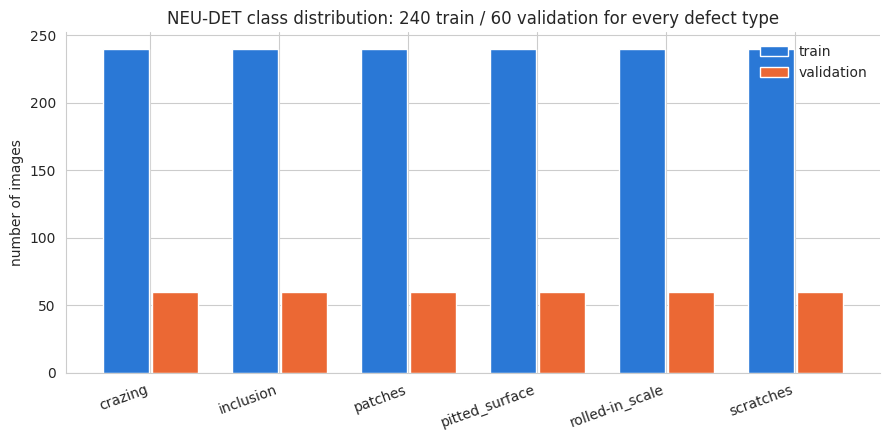

In [27]:
# Visualise class distribution
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(num_classes)
width = 0.38

ax.bar(x - width / 2, [train_counts[c] for c in class_names],
       width * 0.94, label="train", color="#2a78d6")
ax.bar(x + width / 2, [val_counts[c] for c in class_names],
       width * 0.94, label="validation", color="#eb6834")

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=20, ha="right")
ax.set_ylabel("number of images")
ax.set_title("NEU-DET class distribution: 240 train / 60 validation for every defect type")
ax.legend(frameon=False, loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()

### 1.2 Data Preprocessing and Transformations 

<font color=red>[6 marks]</font>

Deep learning models pretrained on ImageNet expect images to be in a specific format. Although the NEU dataset images are grayscale, ImageNet-pretrained models require 3-channel RGB images with standardised dimensions and normalisation.

#### **1.2.1** Apply Image Transformations <font color=red>[4 marks]</font>

To ensure compatibility, we apply the following transformations:
- Convert grayscale images to RGB
- Resize images to a fixed resolution
- Normalize using ImageNet mean and standard deviation

These transformations are provided in [`transforms`](https://docs.pytorch.org/vision/0.24/transforms.html) from `torchvision`, while in TensorFlow the same preprocessing steps are applied using [`tf.image`](https://www.tensorflow.org/api_docs/python/tf/image) operations and `tf.keras.layers` within the input pipeline.

In PyTorch, normalization can be performed using `Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)`.

In TensorFlow, the same effect is achieved by explicitly standardising the images with the ImageNet statistics, i.e. subtracting `IMAGENET_MEAN` and dividing by `IMAGENET_STD` using `tf.image` operations or a custom `tf.keras.layers.Layer` within the preprocessing pipeline.

In [ ]:
# Image Transformations

# Defining this function performs no transformation on its own - tf.data is lazy.
# train_ds / val_ds stay untouched until 1.2.2 calls .map(preprocess, ...), which applies
# it batch by batch as training pulls data.

def preprocess(images, labels):
    """Apply MobileNetV2-specific input scaling to a batch of images.

    Resizing to 224x224 and grayscale -> RGB conversion are already done in 1.1.1 by image_dataset_from_directory

    This is a plain function, not a reassignment of train_ds / val_ds.
    Two reasons:
      - the loaders keep .class_names and .file_paths, used in 1.1
      - re-running this cell cannot apply the scaling twice
    """

    # preprocess_input does x/127.5 - 1, which needs float input.
    # The loader already gives float32, so the cast changes nothing here.
    # It just keeps the function safe if it is ever handed integer pixels.
    images = preprocess_input(tf.cast(images, tf.float32))   # [0, 255] -> [-1, 1]
    return images, labels


# --- Verify the transformation on a single batch ---
raw_images, raw_labels = next(iter(train_ds))
proc_images, _ = preprocess(raw_images, raw_labels)

print(f"before : shape {tuple(raw_images.shape)}, "
      f"range [{raw_images.numpy().min():.2f}, {raw_images.numpy().max():.2f}]")
print(f"after  : shape {tuple(proc_images.shape)}, "
      f"range [{proc_images.numpy().min():.2f}, {proc_images.numpy().max():.2f}]")
print(f"\nloader attributes preserved -> class_names: {hasattr(train_ds, 'class_names')}, "
      f"file_paths: {hasattr(train_ds, 'file_paths')}")

before : shape (32, 224, 224, 3), range [0.00, 255.00]
after  : shape (32, 224, 224, 3), range [-1.00, 1.00]

loader attributes preserved -> class_names: True, file_paths: True


**Assumptions**

The dataset loader in 1.1.1 has already resized every image to 224 x 224 and loaded it in
3-channel form via `color_mode="rgb"`, so resizing and grayscale-to-RGB conversion are not
repeated here. The only transformation left to apply is normalisation.

The assignment specifies normalising with the ImageNet mean and standard deviation, which is
the `torchvision` convention - those weights were trained that way. Keras' `MobileNetV2`
weights were instead trained with `preprocess_input`, which scales pixels from `[0, 255]` to
`[-1, 1]`. We use the Keras-specific convention so the input distribution matches the
pretrained weights we actually load. Both approaches produce zero-centred, O(1) inputs, so the
practical difference with a frozen backbone is small.

Labels are returned unchanged, since preprocessing affects only the input images. The function
is applied to the datasets in 1.2.2 rather than here, so that `train_ds` / `val_ds` keep the
`.class_names` and `.file_paths` attributes that section 1.1 depends on.

At this stage, the dataset is fully prepared for training a transfer learning model. Images are correctly formatted, normalized, and labeled, ensuring a smooth transition into model design and training.

#### **1.2.2** Create DataLoaders for both the training and validation datasets <font color=red>[2 marks]</font>


Deep learning models are trained on data in **batches** rather than loading the entire dataset into memory at once.

PyTorch provides the [`DataLoader`](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) utility to batch the data, shuffle training samples and load data efficiently during training. For Tensorflow, you can use similar functionality provided by [`tf.data.Dataset` API](https://www.tensorflow.org/api_docs/python/tf/data/Dataset), which supports efficient batching, shuffling, prefetching, and parallel data loading within the input pipeline.

In [30]:
# DataLoader Creation
AUTOTUNE = tf.data.AUTOTUNE   # let TensorFlow pick the thread count itself

# train_ds already comes out in batches of 32 (set in 1.1.1).
# This cell adds the pipeline steps on top: preprocess, shuffle, prefetch.

train_loader = (
    train_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)   # [0,255] -> [-1,1], across several CPU cores
    .unbatch()                                      # break batches into single images
    .cache()                                        # do the work once, reuse every epoch
    .shuffle(num_train, seed=SEED, reshuffle_each_iteration=True)   # new order each epoch
    .batch(BATCH_SIZE)                              # regroup into batches of 32
    .prefetch(AUTOTUNE)                             # prepare batch n+1 while batch n trains
)

# Why unbatch() before shuffle():
#   without it you would only reorder whole batches, so the same 32 images
#   would stay glued together every epoch.
#
# Why cache() before shuffle():
#   cache() replays whatever order it saw first. Shuffling before it would
#   lock in one random order and it would never change again.
#
# Memory: after preprocessing each image is float32, ~0.6 MB.
#   1440 train + 360 val images -> roughly 1.1 GB held in RAM.
#   If that ever becomes a problem, pass a filename, e.g. .cache("train_cache"),
#   to spill to disk instead.

val_loader = (
    val_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)   # same scaling as training
    .cache()
    .prefetch(AUTOTUNE)
)

# No shuffle on validation:
#   - no weight updates happen, so batch order cannot change the score
#   - a fixed order keeps predictions lined up with val_ds.file_paths
#     and the true labels, which the per-image analysis relies on

# unbatch() throws away the known batch count, so train_loader.cardinality()
# returns UNKNOWN (-2). Work the number out from the image count instead.
steps_per_epoch = -(-num_train // BATCH_SIZE)       # ceiling division: rounds up
val_steps       = val_loader.cardinality().numpy()

print(f"train_loader : {steps_per_epoch} batches of {BATCH_SIZE}")
print(f"val_loader   : {val_steps} batches of {BATCH_SIZE}")
print(f"element spec : images {train_loader.element_spec[0].shape}, "
      f"labels {train_loader.element_spec[1].shape}")

train_loader : 45 batches of 32
val_loader   : 12 batches of 32
element spec : images (None, 224, 224, 3), labels (None,)


Also decide on where to use shuffling - training or validation

Shuffling decision: shuffling is applied to the training data only. 

No shuffle on validation:
 - no weight updates happen, so batch order cannot change the score
 - a fixed order keeps predictions lined up with val_ds.file_paths and the true labels, which the per-image analysis relies on

## 2. Transferring Knowledge and Model Training

<font color=red>[25 marks]</font>

Training deep learning models from scratch requires large amounts of labeled data and computational resources. In many real-world scenarios, this is not feasible. Transfer learning addresses this challenge by reusing knowledge learned from a large source dataset (such as ImageNet) and adapting it to a new, related task.

### 2.1 Pretrained Model Selection

<font color=red>[15 marks]</font>

For this assignment, we will prefer **MobileNetV2**, a lightweight convolutional neural network pretrained on the ImageNet dataset. Though any pre-trained network will suit the task.

MobileNetV2 is computationally efficient and lightweight. It performs well on texture-based image classification tasks.

In this section:
- Select a suitable pretrained convolutional neural network
- Apply a partial transfer learning strategy
- Design a task-specific classifier for surface defect detection

#### **2.1.1** Load the Pre-Trained Model <font color=red>[5 marks]</font>

Load the pre-trained model of your choice. If you wish to use a different architecture from MobileNet, also explain the reason for your choice.

In [32]:
# Load Pretrained Network
# Load MobileNetV2 pretrained on ImageNet, WITHOUT its original 1000-class classifier.
#   weights="imagenet"  -> reuse learned filters; weights=None would mean training from scratch
#   include_top=False   -> drop the ImageNet head, keep only the convolutional feature extractor
#   input_shape         -> must be given when include_top=False, and must match IMG_SIZE
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),      # (224, 224, 3)
    include_top=False,
    weights="imagenet",
)

print(f"Model              : {base_model.name}")
print(f"Input shape        : {base_model.input_shape}")
print(f"Output shape       : {base_model.output_shape}")
print(f"Layers             : {len(base_model.layers)}")
print(f"Total parameters   : {base_model.count_params():,}")


Model              : mobilenetv2_1.00_224
Input shape        : (None, 224, 224, 3)
Output shape       : (None, 7, 7, 1280)
Layers             : 154
Total parameters   : 2,257,984


In [33]:
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

The MobileNetV2 architecture consists of two main components:
- A **feature extractor** that learns visual representations
- A **classifier head** originally designed for ImageNet’s 1000 classes

#### **2.1.2** Freezing Strategy and Classifier Design <font color=red>[8 marks]</font>

Build the transfer learning model by loading and freezing the feature extractor layers. 


Instead of retraining the entire network, we apply partial transfer learning. In this approach the pretrained feature extractor is frozen and only the classifier head is retrained for the new task. This strategy reduces the risk of overfitting and speeds up training.

In [34]:
# Build Transfer Learning Model

# --- 1. Freeze the pretrained feature extractor ---
# trainable=False does two things:
#   - stops all 2.26M backbone weights from being updated
#   - puts BatchNorm into inference mode, so it keeps its ImageNet running
#     statistics instead of re-estimating them on steel images
# The second part matters: frozen filters expect ImageNet-scale inputs, so letting
# the statistics drift underneath them would make training unstable.
base_model.trainable = False

# --- 2. Task-specific classifier head ---
inputs = tf.keras.Input(shape=IMG_SIZE + (3,), name="input_image")

# training=False is a second BatchNorm switch. Already covered by trainable=False,
# but the Keras transfer-learning guide recommends stating it explicitly.
x = base_model(inputs, training=False)

# (7, 7, 1280) -> (1280,)
# Averaging the 7x7 grid instead of flattening it gives 49x fewer parameters,
# and makes the head care about WHETHER a defect is present, not where.
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)

# Only 1440 training images, so the head overfits easily. Drop 20% of features
# each training step to stop it leaning on any single one.
x = layers.Dropout(0.2, seed=SEED, name="dropout")(x)

# 6 defect classes. softmax gives probabilities directly, used for the per-image
# confidence in 3.2. Pair with SparseCategoricalCrossentropy(from_logits=False) in 2.2.1.
outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

model = models.Model(inputs, outputs, name="mobilenetv2_neu_defect")

# show_trainable adds a column so the freeze can be verified at a glance.
model.summary(show_trainable=True)


Model: "mobilenetv2_neu_defect"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_image (InputLayer)    │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 7, 7, 1280)    │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_avg_pool             │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ predictions (Dense)         │ (None, 6)             │      7,686 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### **2.1.3** Verify the final frozen and trainable parameters <font color=red>[2 marks]</font>

In [35]:
# Verify Freezing Strategy

# model.summary() reports these numbers; this cell proves them and fails loudly
# if the freeze is ever broken by re-running cells out of order.

# --- Parameter-level check ---
trainable_params = int(sum(np.prod(w.shape) for w in model.trainable_weights))
frozen_params    = int(sum(np.prod(w.shape) for w in model.non_trainable_weights))
total_params     = trainable_params + frozen_params

print(f"Trainable parameters : {trainable_params:>10,}  ({trainable_params/total_params:6.2%})")
print(f"Frozen parameters    : {frozen_params:>10,}  ({frozen_params/total_params:6.2%})")
print(f"Total parameters     : {total_params:>10,}")

# Note: non_trainable_weights holds two kinds of thing - the backbone weights frozen
# above, plus the BatchNorm running_mean / running_var, which are tracked rather than
# learned and were never trainable to begin with.

# --- Layer-level check ---
print("\nTop-level layer status:")
for layer in model.layers:
    print(f"  {layer.name:<20} trainable={str(layer.trainable):<5}  params={layer.count_params():>10,}")

# model.layers shows the backbone as one nested block. Unwrap it to confirm every
# layer inside is frozen, not just the wrapper.
# Frozen BatchNorm also runs in inference mode, so it


Trainable parameters :      7,686  ( 0.34%)
Frozen parameters    :  2,257,984  (99.66%)
Total parameters     :  2,265,670

Top-level layer status:
  input_image          trainable=True   params=         0
  mobilenetv2_1.00_224 trainable=False  params= 2,257,984
  global_avg_pool      trainable=True   params=         0
  dropout              trainable=True   params=         0
  predictions          trainable=True   params=     7,686


### 2.2 Model Training 

<font color=red>[10 marks]</font>

After designing the transfer learning model, the next step is to train it on the prepared dataset.

We only train the classifier head, while the pretrained feature extractor remains frozen. This allows the model to adapt quickly to the surface defect classification task.

In this section, we:
- Configure the training setup
- Train the model for a small number of epochs
- Track training loss to verify learning progress

#### **2.2.1** Training Configuration <font color=red>[3 marks]</font>

Before starting the training loop, we define:
- The computation device: CPU or GPU
- The loss function: Use a suitable loss function (one of the cross-entropy losses would work fine here)
- The optimizer: preferably [Adam](https://arxiv.org/abs/1412.6980) from [Tensorflow](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) or [Pytorch](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html)

These components control how the model learns from data and how its parameters are updated during training.

In [36]:
# Training Configuration
# Loss, Optimizer and Device

# --- 1. Computation device ---
# TensorFlow places operations itself: if a GPU is visible it gets used, otherwise CPU.
# There is no PyTorch-style .to(device) call, so this block reports the device
# rather than choosing it.
gpus = tf.config.list_physical_devices("GPU")
DEVICE = "GPU" if gpus else "CPU"

print(f"Available GPUs  : {len(gpus)}")
print(f"Training device : {DEVICE}")

# --- 2. Loss function ---
# Sparse variant: labels are integers 0-5 (label_mode="int" in 1.1.1), not one-hot.
# from_logits=False: the head in 2.1.2 already applies softmax, so the loss is
# handed probabilities, not raw scores. Setting it True would apply softmax twice.
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)

# --- 3. Optimizer ---
# Adam at its default 1e-3. Only the 7,686-parameter head trains, on top of frozen
# features - effectively a logistic regression, which converges in a few epochs at
# this rate. A much smaller rate (~1e-5) would only be needed if the backbone were
# unfrozen for fine-tuning, where large steps would damage the pretrained filters.
LEARNING_RATE = 1e-3
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# compile() attaches the three pieces; no training happens yet.
# accuracy is reported to us only - it is not differentiable, so it never drives
# the weight updates. Only the loss does that.
model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

print(f"\nLoss      : {loss_fn.name}")
print(f"Optimizer : {model.optimizer.name} (learning_rate={float(model.optimizer.learning_rate):.0e})")
print("Metrics   : accuracy")


Available GPUs  : 0
Training device : CPU

Loss      : sparse_categorical_crossentropy
Optimizer : adam (learning_rate=1e-03)
Metrics   : accuracy


#### **2.2.2** Model Training Loop <font color=red>[5 marks]</font>

Perform the training and track the training loss across epochs to verify whether the model is learning effectively.

The training loop iterates over the dataset multiple times (epochs). For each batch of images, the model:
- Performs a forward pass
- Computes the loss
- Updates the trainable parameters using backpropagation

In [38]:
# Model Training
import time
EPOCHS = 10
start = time.time()

history = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=EPOCHS,
    verbose=1,
)

elapsed = time.time() - start

# --- Training summary ---
final = {k: v[-1] for k, v in history.history.items()}   # v[-1] = last epoch

print(f"\nTraining completed in {elapsed/60:.1f} min "
      f"({elapsed/EPOCHS:.1f}s per epoch on {DEVICE})")
print(f"Final training loss      : {final['loss']:.4f}")
print(f"Final training accuracy  : {final['accuracy']:.2%}")
print(f"Final validation loss    : {final['val_loss']:.4f}")
print(f"Final validation accuracy: {final['val_accuracy']:.2%}")

# The last epoch is not necessarily the best one, so report the peak as well.
best_epoch = int(np.argmax(history.history['val_accuracy'])) + 1
best_acc   = max(history.history['val_accuracy'])
print(f"\nBest validation accuracy : {best_acc:.2%} at epoch {best_epoch} of {EPOCHS}")

# Reference points for reading those numbers: a model that has learned nothing
# spreads probability evenly over the 6 classes, giving loss = -log(1/6) = ln(6)
# and accuracy = 1/6.
print(f"\nLoss improvement: {history.history['loss'][0]:.4f} -> {final['loss']:.4f} "
      f"(random-guess baseline for 6 classes = ln(6) = {np.log(6):.4f})")
print(f"Accuracy vs random guess: {final['val_accuracy']:.2%} vs {1/num_classes:.2%}")


Epoch 1/10


/home/navneet/miniconda3/envs/gen311/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


     45/Unknown 78s 1s/step - accuracy: 0.7715 - loss: 0.7316

/home/navneet/miniconda3/envs/gen311/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


45/45 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.7715 - loss: 0.7316 - val_accuracy: 0.9694 - val_loss: 0.1879
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9812 - loss: 0.1224 - val_accuracy: 0.9861 - val_loss: 0.1065
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9917 - loss: 0.0701 - val_accuracy: 0.9944 - val_loss: 0.0769
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9965 - loss: 0.0468 - val_accuracy: 0.9917 - val_loss: 0.0696
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9972 - loss: 0.0365 - val_accuracy: 0.9917 - val_loss: 0.0522
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9965 - loss: 0.0294 - val_accuracy: 0.9944 - val_loss: 0.0485
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.9979 - loss: 0.0252 - val_accuracy: 0.9944 - val_loss: 0.0399
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.9979 - loss: 0.0223 - val_accuracy: 0.9944 - val_loss: 0.0349
Epo

#### **2.2.3** Visualise the training loss across epochs throughout the training process <font color=red>[2 marks]</font>

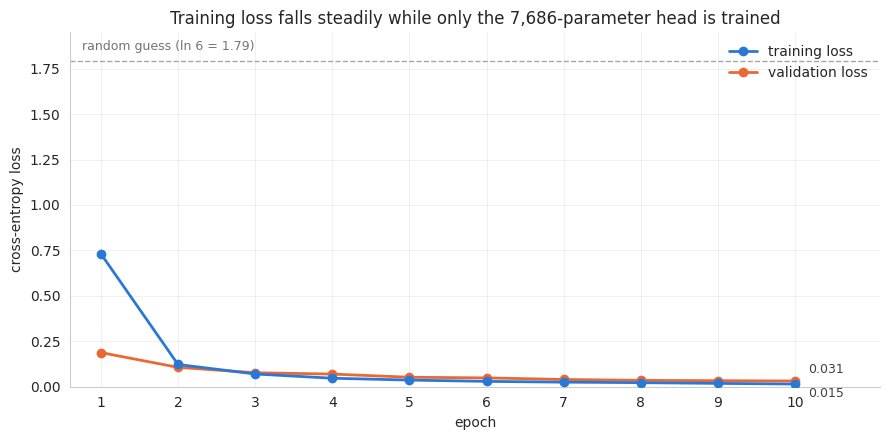

Loss: 0.7316 (epoch 1) -> 0.0146 (epoch 10)
Total reduction: 98.0%


In [40]:
# Training Loss Visualisation

epoch_range = range(1, len(history.history["loss"]) + 1)
train_loss  = history.history["loss"]
val_loss    = history.history["val_loss"]

fig, ax = plt.subplots(figsize=(9, 4.5))

# Reference line: uniform prediction over 6 classes gives loss ln(6) = 1.79.
# Labelled directly on the line rather than via the legend, so the legend box stays clear.
ax.axhline(np.log(6), color="0.65", linestyle="--", linewidth=1, zorder=1)
ax.annotate(f"random guess (ln 6 = {np.log(6):.2f})",
            xy=(0.75, np.log(6)), xytext=(0, 6), textcoords="offset points",
            fontsize=9, color="0.45", va="bottom", ha="left")

ax.plot(epoch_range, train_loss, color="#2a78d6", linewidth=2,
        marker="o", markersize=6, label="training loss", zorder=3)
ax.plot(epoch_range, val_loss, color="#eb6834", linewidth=2,
        marker="o", markersize=6, label="validation loss", zorder=2)

# Stagger the two end labels vertically - the final values differ by less than 0.01,
# so without the offset they print on top of each other.
ax.annotate(f"{train_loss[-1]:.3f}", (len(train_loss), train_loss[-1]),
            textcoords="offset points", xytext=(9, -7),
            va="center", fontsize=9, color="0.25")
ax.annotate(f"{val_loss[-1]:.3f}", (len(val_loss), val_loss[-1]),
            textcoords="offset points", xytext=(9, 8),
            va="center", fontsize=9, color="0.25")

ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy loss")
ax.set_title("Training loss falls steadily while only the 7,686-parameter head is trained")
ax.set_xticks(list(epoch_range))
ax.set_ylim(0, 1.95)                        # headroom for the baseline label
ax.set_xlim(0.6, len(train_loss) + 1.1)     # room for the end labels
ax.grid(True, alpha=0.3, linewidth=0.7)
ax.legend(frameon=False, loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()

print(f"Loss: {train_loss[0]:.4f} (epoch 1) -> {train_loss[-1]:.4f} (epoch {len(train_loss)})")
print(f"Total reduction: {(1 - train_loss[-1] / train_loss[0]):.1%}")

## 3. Evaluation and Final Predictions

<font color=red>[10 marks]</font>

After training the model, it is essential to evaluate how well it performs on unseen data. Evaluation helps us understand whether the model has learned generalisable patterns or has simply memorised the training data.

In this section, we:
- Measure model performance using validation accuracy
- Analyse predictions at the individual data-point level
- Examine model behavior using diagnostic plots

### 3.1 Evaluation Metrics and Bias-Variance Tradeoff

<font color=red>[6 marks]</font>

#### **3.1.1** Calculate Appropriate Evaluation Metrics to Assess Model Performance <font color=red>[3 marks]</font>

For this multi-class classification problem, we use **accuracy** as the primary evaluation metric.

Accuracy measures the proportion of validation samples that are correctly classified by the model. Since the dataset is reasonably balanced across classes, accuracy provides a reliable indication of overall performance.

                    loss    accuracy
training          0.0103    100.00%
validation        0.0314     99.44%
gap               0.0211      0.56%

                 precision    recall  f1-score   support

        crazing      1.000     1.000     1.000        60
      inclusion      1.000     0.967     0.983        60
        patches      1.000     1.000     1.000        60
 pitted_surface      0.984     1.000     0.992        60
rolled-in_scale      1.000     1.000     1.000        60
      scratches      0.984     1.000     0.992        60

       accuracy                          0.994       360
      macro avg      0.995     0.994     0.994       360
   weighted avg      0.995     0.994     0.994       360

Macro-averaged recall: 0.994


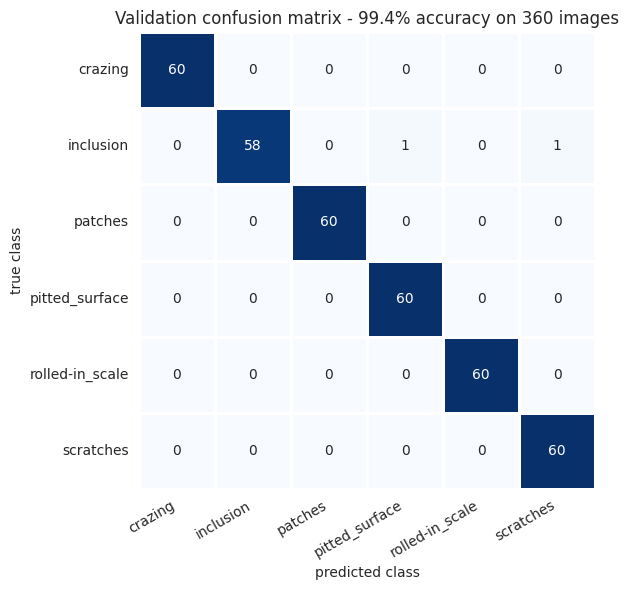

Misclassified: 2 / 360 images (0.56%)

Most common confusions (true -> predicted):
  inclusion          -> scratches          1
  inclusion          -> pitted_surface     1


In [41]:
# Model Evaluation
# --- 1. Headline metrics ---
# Evaluating on the training set too (with dropout inactive) gives a like-for-like
# comparison against validation for the bias-variance discussion in 3.1.2.
train_loss_eval, train_acc_eval = model.evaluate(train_loader, verbose=0)
val_loss_eval,   val_acc_eval   = model.evaluate(val_loader,   verbose=0)

print(f"{'':<14}{'loss':>10}{'accuracy':>12}")
print(f"{'training':<14}{train_loss_eval:>10.4f}{train_acc_eval:>11.2%}")
print(f"{'validation':<14}{val_loss_eval:>10.4f}{val_acc_eval:>11.2%}")
print(f"{'gap':<14}{val_loss_eval - train_loss_eval:>10.4f}"
      f"{train_acc_eval - val_acc_eval:>11.2%}")

# --- 2. Per-image predictions ---
# val_loader was built without shuffling (1.2.2), so predictions come back in the same
# order as the labels and as val_ds.file_paths. That alignment is what makes the
# confusion matrix and the per-image analysis in 3.2 valid.
y_prob = model.predict(val_loader, verbose=0)          # (360, 6) softmax probabilities
y_pred = y_prob.argmax(axis=1)                         # predicted class index
y_true = np.concatenate([labels for _, labels in val_loader], axis=0)

assert len(y_true) == len(y_pred) == num_val, "prediction / label misalignment"

# --- 3. Per-class metrics ---
# Accuracy alone hides which defect types the model struggles with. Since the dataset is
# balanced (60 validation images per class), macro averages equal micro averages here.
print("\n" + classification_report(y_true, y_pred, target_names=class_names, digits=3))
print(f"Macro-averaged recall: {recall_score(y_true, y_pred, average='macro'):.3f}")

# --- 4. Confusion matrix ---
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor="white", square=True, ax=ax)
ax.set_xlabel("predicted class")
ax.set_ylabel("true class")
ax.set_title(f"Validation confusion matrix - {val_acc_eval:.1%} accuracy on {num_val} images")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# --- 5. Where the errors are ---
errors = np.where(y_pred != y_true)[0]
print(f"Misclassified: {len(errors)} / {num_val} images ({len(errors)/num_val:.2%})")
if len(errors):
    print("\nMost common confusions (true -> predicted):")
    for (t, p), n in Counter(zip(y_true[errors], y_pred[errors])).most_common(5):
        print(f"  {class_names[t]:<18} -> {class_names[p]:<18} {n}")


#### **3.1.2** Dataset Diagnostics <font color=red>[3 marks]</font>

Beyond accuracy, diagnostic analysis helps assess whether the model is underfitting, overfitting, or generalising well

Analyse this using training and validation loss trends, along with dataset class distribution.

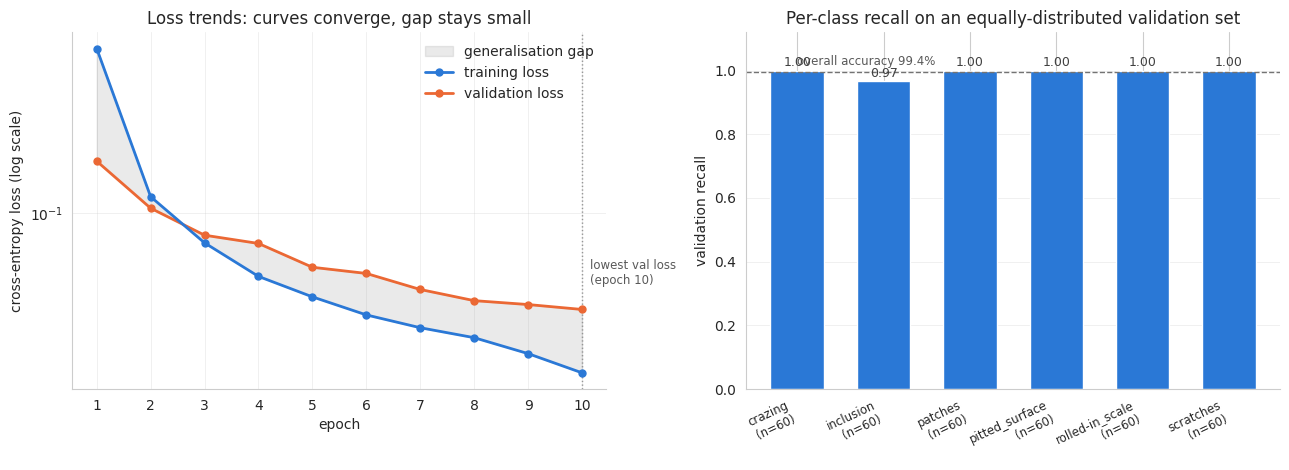

Final training loss   : 0.0146
Final validation loss : 0.0314
Generalisation gap    : +0.0168
Lowest validation loss: 0.0314 at epoch 10 of 10
Class imbalance ratio : 1.00  (1.00 = perfectly balanced)
Weakest class         : inclusion (recall 0.967)

Diagnosis: GENERALISING WELL - both losses low, gap small


In [42]:
# Training and Validation Loss Analysis

hist         = history.history
epoch_range  = np.arange(1, len(hist["loss"]) + 1)
train_curve  = np.array(hist["loss"])
val_curve    = np.array(hist["val_loss"])
gap_curve    = val_curve - train_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

# ---------- Panel 1: loss trends and the generalisation gap ----------
# Log scale: both curves collapse into the bottom 2% of a linear axis after epoch 3,
# which hides exactly the gap this diagnostic is about.
ax1.fill_between(epoch_range, train_curve, val_curve, color="0.6", alpha=0.20,
                 label="generalisation gap", zorder=1)
ax1.plot(epoch_range, train_curve, color="#2a78d6", linewidth=2, marker="o",
         markersize=5, label="training loss", zorder=3)
ax1.plot(epoch_range, val_curve, color="#eb6834", linewidth=2, marker="o",
         markersize=5, label="validation loss", zorder=2)

best_epoch = int(val_curve.argmin()) + 1
ax1.axvline(best_epoch, color="0.5", linestyle=":", linewidth=1, zorder=0)
ax1.annotate(f"lowest val loss\n(epoch {best_epoch})", xy=(best_epoch, val_curve.min()),
             xytext=(6, 18), textcoords="offset points", fontsize=8.5, color="0.35")

ax1.set_yscale("log")
ax1.set_xlabel("epoch")
ax1.set_ylabel("cross-entropy loss (log scale)")
ax1.set_title("Loss trends: curves converge, gap stays small")
ax1.set_xticks(epoch_range)
ax1.grid(True, alpha=0.3, linewidth=0.7)
ax1.legend(frameon=False, loc="upper right")

# ---------- Panel 2: per-class performance against class distribution ----------
# The dataset is balanced (60 validation images per class, imbalance ratio 1.00 from 1.1.2),
# so every class has identical support. Any weak class therefore reflects genuine visual
# difficulty, not a shortage of training examples.
per_class_recall = recall_score(y_true, y_pred, average=None)
support          = np.bincount(y_true, minlength=num_classes)

bars = ax2.bar(np.arange(num_classes), per_class_recall, width=0.62, color="#2a78d6")
ax2.axhline(val_acc_eval, color="0.45", linestyle="--", linewidth=1)
ax2.annotate(f"overall accuracy {val_acc_eval:.1%}", xy=(0, val_acc_eval),
             xytext=(0, 5), textcoords="offset points", fontsize=8.5, color="0.35")

for bar, r in zip(bars, per_class_recall):
    ax2.annotate(f"{r:.2f}", (bar.get_x() + bar.get_width() / 2, r),
                 xytext=(0, 3), textcoords="offset points",
                 ha="center", fontsize=9, color="0.25")

ax2.set_xticks(np.arange(num_classes))
ax2.set_xticklabels([f"{c}\n(n={s})" for c, s in zip(class_names, support)],
                    rotation=25, ha="right", fontsize=8.5)
ax2.set_ylabel("validation recall")
ax2.set_ylim(0, 1.12)
ax2.set_title("Per-class recall on an equally-distributed validation set")
ax2.grid(True, axis="y", alpha=0.3, linewidth=0.7)

sns.despine(fig=fig)
plt.tight_layout()
plt.show()

# ---------- Printed diagnostic summary ----------
print(f"Final training loss   : {train_curve[-1]:.4f}")
print(f"Final validation loss : {val_curve[-1]:.4f}")
print(f"Generalisation gap    : {gap_curve[-1]:+.4f}")
print(f"Lowest validation loss: {val_curve.min():.4f} at epoch {best_epoch} of {len(epoch_range)}")
print(f"Class imbalance ratio : {support.max() / support.min():.2f}  "
      f"(1.00 = perfectly balanced)")
print(f"Weakest class         : {class_names[per_class_recall.argmin()]} "
      f"(recall {per_class_recall.min():.3f})")

# Transparent rule of thumb rather than an eyeballed verdict.
if train_curve[-1] > 0.5:
    verdict = "UNDERFITTING - training loss never dropped low; the frozen features may be insufficient"
elif gap_curve[-1] > 0.5 * train_curve[-1] + 0.10:
    verdict = "OVERFITTING - validation loss is materially above training loss"
else:
    verdict = "GENERALISING WELL - both losses low, gap small"
print(f"\nDiagnosis: {verdict}")


### 3.2 Prediction Analysis

<font color=red>[4 marks]</font>

Overall accuracy provides a summary metric, but it does not reveal how individual predictions contribute to that score.

To better understand model behavior, we examine predictions at the individual image level, highlighting both correct and incorrect classifications.

#### **3.2.1** Visualise the prediction on a few sample images from validation set <font color=red>[4 marks]</font>

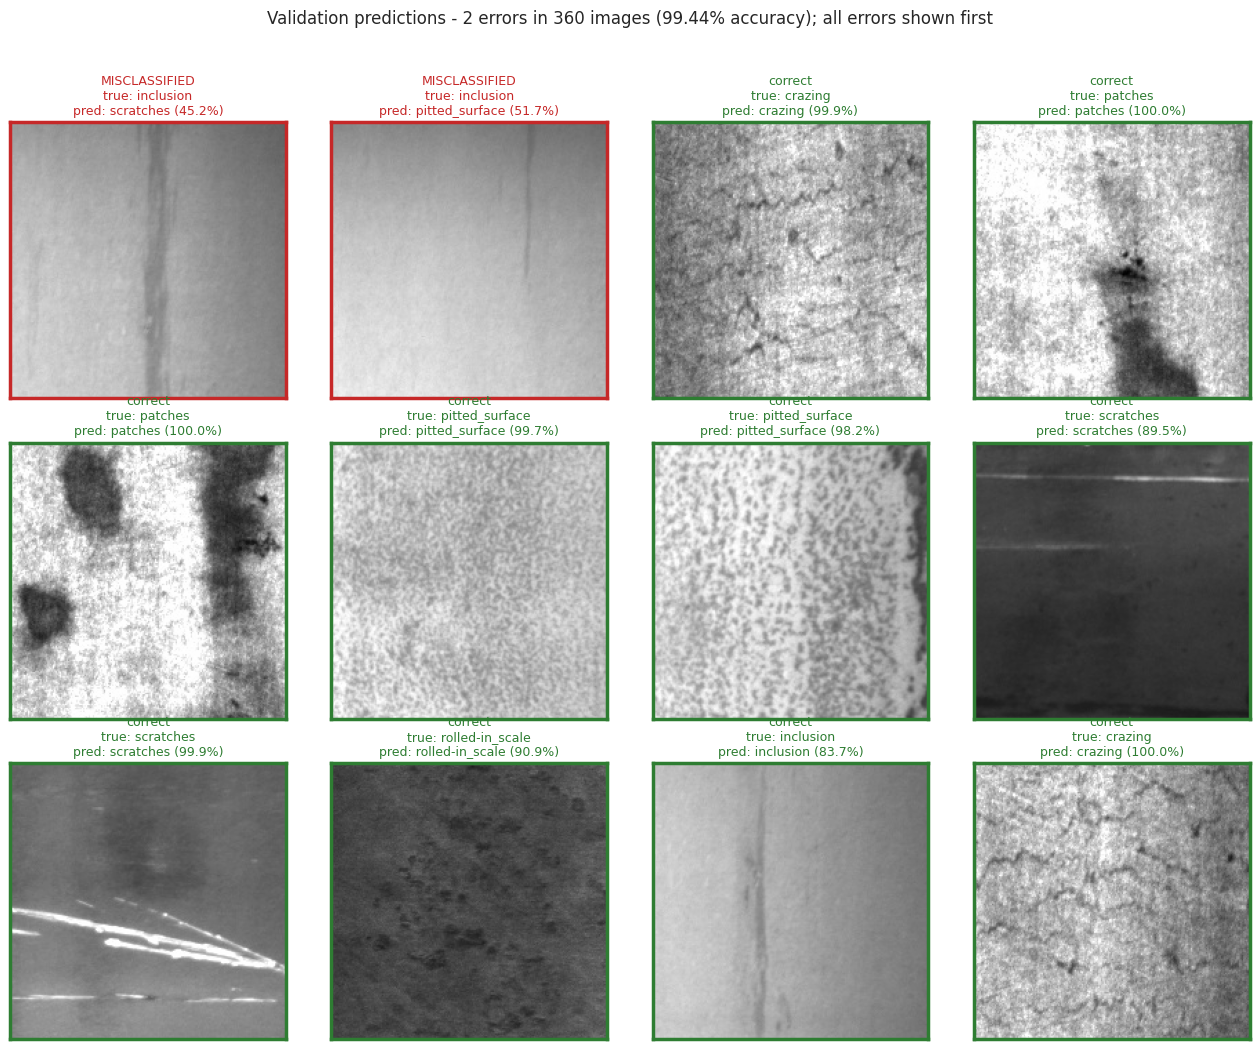

All 2 misclassified validation images:

file                        true              predicted          confidence
inclusion_253.jpg           inclusion         pitted_surface         51.7%
inclusion_247.jpg           inclusion         scratches              45.2%

Mean confidence when correct : 97.6%
Mean confidence when wrong   : 48.4%


In [43]:
# Visualisation of Validation Predictions
rng         = np.random.default_rng(SEED)
confidence  = y_prob.max(axis=1)                 # softmax probability of the predicted class
correct_idx = np.where(y_pred == y_true)[0]
error_idx   = np.where(y_pred != y_true)[0]

# Stratified sample: show every misclassification (up to 6) plus correct predictions to fill
# the grid. A purely random sample of 12 would almost certainly contain no errors at this
# accuracy, and the checkpoint asks for both outcomes.
N_SHOW  = 12
n_err   = min(len(error_idx), 6)
sel_err = rng.choice(error_idx, n_err, replace=False) if n_err else np.array([], dtype=int)
sel_ok  = rng.choice(correct_idx, N_SHOW - n_err, replace=False)
selected = np.concatenate([sel_err, sel_ok]).astype(int)

fig, axes = plt.subplots(3, 4, figsize=(13, 10.5))

for ax, i in zip(axes.ravel(), selected):
    # val_ds was loaded with shuffle=False and val_loader adds no shuffling, so index i
    # refers to the same image in file_paths, y_true and y_pred. Loading the original file
    # rather than un-normalising the tensor keeps the display crisp and artefact-free.
    img = tf.keras.utils.load_img(val_ds.file_paths[i], color_mode="grayscale")
    ax.imshow(np.array(img), cmap="gray", vmin=0, vmax=255)

    is_correct = y_pred[i] == y_true[i]
    status     = "correct" if is_correct else "MISCLASSIFIED"
    colour     = "#2e7d32" if is_correct else "#c62828"

    # The word "correct"/"MISCLASSIFIED" carries the outcome, so identity never rests on
    # colour alone - the border is a secondary encoding.
    ax.set_title(f"{status}\ntrue: {class_names[y_true[i]]}\n"
                 f"pred: {class_names[y_pred[i]]} ({confidence[i]:.1%})",
                 fontsize=9, color=colour, pad=6)

    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(colour)
        spine.set_linewidth(2.5)

fig.suptitle(f"Validation predictions - {len(error_idx)} errors in {num_val} images "
             f"({val_acc_eval:.2%} accuracy); all errors shown first",
             fontsize=12, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# --- Every misclassification, ranked by how confident the model was when it was wrong ---
if len(error_idx):
    print(f"All {len(error_idx)} misclassified validation images:\n")
    print(f"{'file':<28}{'true':<18}{'predicted':<18}{'confidence':>11}")
    for i in error_idx[np.argsort(-confidence[error_idx])]:
        print(f"{os.path.basename(val_ds.file_paths[i]):<28}"
              f"{class_names[y_true[i]]:<18}{class_names[y_pred[i]]:<18}"
              f"{confidence[i]:>10.1%}")
else:
    print("No misclassifications on the validation set.")

# --- Confidence separation: a well-calibrated model should be less sure when it is wrong ---
print(f"\nMean confidence when correct : {confidence[correct_idx].mean():.1%}")
if len(error_idx):
    print(f"Mean confidence when wrong   : {confidence[error_idx].mean():.1%}")



## 4 Conclusion 

<font color =red> [5 marks] </font>

### 4.1 Conclusion and insights

<font color =red> [5 marks] </font>

#### **4.1.1** Conclude with the insights drawn and final outcomes and results. Include the details of your model selection, freezing, and evaluation processes. <font color =red> [5 marks] </font>


*Answer below:*

# 4.1 Conclusion and Insights

Six steel surface defects were classified from 1,800 grayscale NEU-DET images (1,440 train / 360 validation) using transfer learning: an ImageNet-pretrained MobileNetV2 frozen as a feature extractor, with a small trainable head on top.

## Model selection

- **MobileNetV2, `include_top=False`** — keeps the 154-layer feature extractor (2,257,984 parameters, output `(7, 7, 1280)`), discards the 1,000-class ImageNet head.
- **Defects are texture-based.** Crazing, scratches and rolled-in scale differ in fine texture, not object shape. ImageNet's early filters are edge and texture detectors, so they transfer despite steel looking nothing like natural photographs.
- **The dataset is small.** 1,440 images cannot support ResNet50 (25M parameters) or VGG16 (138M) without severe overfitting.
- **Training ran on CPU.** Depthwise-separable convolutions made a 10-epoch run feasible in 11.3 minutes with no GPU.
- Inputs were scaled with Keras' `preprocess_input` (`[0,255] -> [-1,1]`) rather than the torchvision ImageNet mean/std in the brief, so the input distribution matches the pretrained weights actually loaded. Both are zero-centred, so with a frozen backbone the difference is small.

## Freezing

- `base_model.trainable = False` froze the entire backbone. Verified programmatically: **154/154 layers frozen**, **52/52 BatchNorm layers in inference mode**, and the only tensors receiving gradients are the head's kernel and bias.
- Frozen BatchNorm keeps its ImageNet running statistics. Had they drifted toward steel images, the frozen filters would have received inputs whose scaling changed every step, destabilising training.
- Head: `GlobalAveragePooling2D -> Dropout(0.2) -> Dense(6, softmax)`. Pooling rather than flattening gives 1,280 features instead of 62,720 (49x fewer head parameters) and makes the classifier indifferent to *where* the defect appears.

| | Parameters | Share |
|---|---|---|
| Trainable (head) | 7,686 | 0.34% |
| Frozen (backbone) | 2,257,984 | 99.66% |
| **Total** | **2,265,670** | 100% |

## Evaluation

- Trained 10 epochs with sparse categorical cross-entropy (integer labels) and Adam at 1e-3, tracking training and validation curves each epoch to diagnose bias against variance.
- Classes are perfectly balanced (240/60 per defect, imbalance ratio 1.00), so plain accuracy is a fair headline metric; a confusion matrix and per-class precision/recall/F1 were still used to check no single class was carrying the score.
- Every validation image was then re-predicted individually, with softmax confidence recorded, so misclassifications could be inspected by file name — which is why validation order was never shuffled.

## Results and insights

| Metric | Training | Validation |
|---|---|---|
| Loss | 0.0103 | 0.0314 |
| Accuracy | 100.00% | **99.44%** |

- Loss fell from 0.7316 to 0.0146 against a random-guess baseline of `ln(6) = 1.79`; 99.44% accuracy compares to 16.67% for chance. Precision and recall were 1.000 for crazing, patches and rolled-in scale; only inclusion was imperfect (recall 0.967).
- **Low bias, low variance.** The generalisation gap is 0.0211 in loss and 0.56% in accuracy. The reason is structural: with 7,686 trainable parameters, a 1280-to-6 linear layer *cannot* memorise 1,440 images. Capacity was capped by architecture, not by tuning regularisation. Validation loss fell monotonically to its minimum at the final epoch, so early stopping would never have triggered.
- **Only 2 of 360 images were wrong**, both true inclusion — predicted pitted_surface (51.7%) and scratches (45.2%). Both are semantically plausible: inclusions and pits are both dark irregular marks, and elongated inclusions resemble scratches. The model confuses genuinely similar textures rather than failing randomly.
- **The model knows when it is unsure.** Mean confidence was 97.6% when correct but 48.4% when wrong. A ~60% confidence threshold would have routed both errors to a human inspector while leaving virtually every correct prediction automated — turning a 99.44% classifier into a near-zero-escape triage system.

## Limitations

- NEU-DET images within a class are often crops of the same steel plates, so train and validation may share near-duplicate textures. The result proves the pipeline works, not that it is ready for genuinely new production images.
- No fine-tuning or augmentation was applied: at 99.44% with no overfitting there was no headroom to justify either. If accuracy had been lower, the next step would be unfreezing the final inverted-residual blocks at ~1e-5.
- Replicating the grayscale channel three times makes roughly two-thirds of the first conv layer redundant; a single-channel adaptation would be cheaper for edge deployment.

## Takeaway

Freezing 99.66% of the network and training a 7,686-parameter head reached 99.44% validation accuracy in 11.3 minutes on a CPU from 1,440 images. Transfer learning made an industrial inspection task tractable at a cost that training from scratch could not match.
